### You can find various implementations of the decoding algorithm in the following.
https://github.com/KordingLab/Neural_Decoding/tree/master

# Spike train decoding for brain-machine interface

For use in decoding, we need the following format of inputs:
- Neural data should be a matrix of size "number of time bins" x "number of neurons", where each entry is the firing rate of a given neuron in a given time bin
- The output you are decoding should be a matrix of size "number of time bins" x "number of features you are decoding"

In this example, we load Matlab data that contains 
- The spike times of all neurons. In Matlab, "spike_times" is a cell of size "number of neurons" x 1. Within spike_times{i} is a vector containing all the spike times of neuron i.
- A continuous stream of the output variables. In this example, we are aiming to decode velocity. In Matlab, "vels" is a matrix of size "number of recorded time points" x 2 (x and y velocities were recorded) that contains the x and y velocity components at all time points. "vel_times" is a vector that states the time at all recorded time points. 



In [51]:
###Import standard packages###
%matplotlib inline

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from collections import namedtuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import io, stats
import pickle
%matplotlib inline
from numpy.linalg import inv as inv #Used in kalman filter
from sklearn import linear_model
from sklearn.svm import SVR

###Import function decoding metrics
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import seaborn as sns

# import keras
# keras_v1=int(keras.__version__[0])<=1
# from keras.models import Sequential
# from keras.layers import Dense, LSTM, Activation, Dropout
# from keras.utils import np_utils

### Load Data

In [36]:
###Load Data###
# folder='./'
data=io.loadmat('m1_data_raw.mat')
spike_times=data['spike_times'] #Load spike times of all neurons
velxy=data['vels'] #Load x and y velocities
# posxy = data['pos']
# accxy = data['acc']
vel_times=data['vel_times'] #Load times at which velocities were recorded

### Linear decoder

In [37]:
class LinearDecoder():
    
    """
    Class for the Linear Decoder. There are no parameters to set.
    This simply leverages the scikit-learn linear regression.
    """
    
    def __init__(self):
        return
    
    def fit(self, X_flat_train, y_train):
        
        """
        Train Linear Decoder

        Parameters
        ----------
        X_flat_train: numpy 2d array of shape [n_samples,n_features]
            This is the neural data.
            See example file for an example of how to format the neural data correctly

        y_train: numpy 2d array of shape [n_samples, n_outputs]
            This is the outputs that are being predicted
        """
        
        self.model = linear_model.LinearRegression()  # Initialize linear regression model
        self.model.fit(X_flat_train, y_train)  # Train the model
        
    def predict(self,X_flat_test):

        """
        Predict outcomes using trained Wiener Cascade Decoder

        Parameters
        ----------
        X_flat_test: numpy 2d array of shape [n_samples,n_features]
            This is the neural data being used to predict outputs.

        Returns
        -------
        y_test_predicted: numpy 2d array of shape [n_samples,n_outputs]
            The predicted outputs
        """

        y_test_predicted=self.model.predict(X_flat_test) #Make predictions
        return y_test_predicted


### Kalman filter decoder

In [93]:
class KalmanFilterDecoder():
    
    """
    Class for the Kalman Filter Decoder
    
    Reference: 
    (https://papers.nips.cc/paper/2178-neural-decoding-of-cursor-motion-using-a-kalman-filter.pdf)
    The original implementation has previously been coded in Matlab by Dan Morris (http://dmorris.net/projects/neural_decoding.html#code)

    """

    def __init__(self):
        return

    def fit(self, X_kf_train, y_train):

        """
        Train Kalman Filter Decoder

        Parameters
        ----------
        X_kf_train: numpy 2d array of shape [n_samples(i.e. timebins) , n_neurons]
            This is the neural data in Kalman filter format.
            See example file for an example of how to format the neural data correctly

        y_train: numpy 2d array of shape [n_samples(i.e. timebins), n_outputs]
            This is the outputs that are being predicted
        """

        # Rename and reformat the variables to be in a more standard Kalman filter nomenclature (from Wu et al, 2003)
        xs = y_train.T
        zs = X_kf_train.T

        # Calculate the transition matrix (from x_t to x_t+1) using least-squares, and compute its covariance
        # In our case, this is the transition from one kinematic state to the next
        nt = xs.shape[1]
        xs2 = xs[:, 1:]
        xs1 = xs[:, :nt - 1]
        A = xs2 @ xs1.T @ inv(xs1 @ xs1.T)  # Transition matrix
        W = (xs2 - A @ xs1) @ (xs2 - A @ xs1).T / (nt - 1)  # Covariance of transition matrix. Note we divide by nt-1 since only nt-1 points were used in the computation (that's the length of X1 and X2). We also introduce the extra parameter C here.

        # Calculate the measurement matrix (from x_t to z_t) using least-squares, and compute its covariance
        # In our case, this is the transformation from kinematics to spikes
        H = zs @ xs.T @ inv(xs @ xs.T)  # Measurement matrix
        Q = (zs - H @ xs) @ ((zs - H @ xs).T) / nt  # Covariance of measurement matrix
        params = [A, W, H, Q]
        self.model = params

    def predict(self, X_kf_test, y_test):    
    #Extract parameters
        A,W,H,Q=self.model

        #First we'll rename and reformat the variables to be in a more standard kalman filter nomenclature (specifically that from Wu et al):
        #xs are the state (here, the variable we're predicting, i.e. y_train)
        #zs are the observed variable (neural data here, i.e. X_kf_train)
        X=np.array(y_test.T)
        Z=np.array(X_kf_test.T)

        #Initializations
        num_states=X.shape[0] #Dimensionality of the state
        states=np.empty(X.shape) #Keep track of states over time (states is what will be returned as y_test_predicted)
        P_m=np.array(np.zeros([num_states,num_states]))
        P=np.array(np.zeros([num_states,num_states]))
        state=X[:,0] #Initial state
        states[:,0]=np.copy(np.squeeze(state))

        #Get predicted state for every time bin
        for t in range(X.shape[1]-1):
            #Do first part of state update - based on transition matrix
            P_m=A@P@A.T+W
            state_m=A@state

            #Do second part of state update - based on measurement matrix
            K=P_m@H.T@inv(H@P_m@H.T+Q) #Calculate Kalman gain
            P=(np.array(np.eye(num_states))-K@H)@P_m
            state=state_m+K@(Z[:,t+1]-H@state_m)
            states[:,t+1]=np.squeeze(state) #Record state at the timestep
        y_test_predicted=states.T
        return y_test_predicted


### LSTM decoder

In [40]:

class LSTMRegression(nn.Module):
    def __init__(self, input_size, output_size, units=400, dropout=0, num_epochs=100, verbose=0):
        super(LSTMRegression, self).__init__()
        self.units = units
        self.dropout = dropout
        self.num_epochs = num_epochs
        self.verbose = verbose
        self.lstm = nn.LSTM(input_size=input_size, 
                           hidden_size=self.units, dropout=self.dropout, batch_first=True)
        self.dropout_layer = nn.Dropout(self.dropout)
        self.linear = nn.Linear(self.units, output_size)
    
    def forward(self, x):
        output, _ = self.lstm(x)
        output = self.dropout_layer(output)
        output = self.linear(output[:, -1, :])
        return output

    def fit(self, X_train, y_train):
        self.train()
        criterion = nn.MSELoss()
        optimizer = optim.RMSprop(self.parameters())

        for epoch in range(self.num_epochs):
            optimizer.zero_grad()

            inputs = torch.Tensor(X_train)
            targets = torch.Tensor(y_train)

            outputs = self(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            if self.verbose and epoch % 10 == 0:
                print(f"Epoch {epoch+1}/{self.num_epochs}, Loss: {loss.item():.4f}")

    def predict(self, X_test):
        self.eval()
        with torch.no_grad():
            inputs = torch.Tensor(X_test)
            outputs = self(inputs)
        return outputs.numpy()


### Functions for preprocessing

In [41]:
######## bin_neural_data ########
def bin_neural_data(spike_times, dt, start_time, end_time):
    """
    Bin spike times into time bins of length dt.

    Parameters
    ----------
    spike_times: array of arrays
        Each inner array contains the spike times for a single neuron.
    dt: float
        Length of time bin.
    start_time: float
        Start time for binning.
    end_time: float
        End time for binning.

    Returns
    -------
    neural_data: matrix of size "number of time bins" x "number of neurons"
        The number of spikes in each time bin for each neuron.
    """
    bin_edges = np.arange(start_time, end_time, dt)
    num_bins = bin_edges.shape[0] - 1
    num_neurons = spike_times.shape[0]
    neural_data = np.empty([num_bins, num_neurons])
    for i in range(num_neurons):
        neural_data[:, i] = np.histogram(spike_times[i], bin_edges)[0]
    return neural_data


######## bin_output_data #######
def bin_output_data(outputs, output_times, dt, start_time, end_time, downsample_factor=1):
    """
    Bin output data into time bins of length dt.

    Parameters
    ----------
    outputs: matrix of size "number of times the output was recorded" x "number of output features"
        Each entry in the matrix is the value of the output feature.
    output_times: vector of size "number of times the output was recorded"
        Each entry has the time the output was recorded.
    dt: float
        Length of time bin.
    start_time: float
        Start time for binning.
    end_time: float
        End time for binning.
    downsample_factor: integer, optional, default=1
        How much to downsample the outputs prior to binning.
        Larger values will increase speed, but decrease precision.

    Returns
    -------
    output_data: matrix of size "number of time bins" x "number of output features"
        The average value of each output feature in every time bin.
    """
    if downsample_factor != 1:
        downsampled_idxs = np.arange(0, output_times.shape[0], downsample_factor)
        outputs = outputs[downsampled_idxs, :]
        output_times = output_times[downsampled_idxs]

    bin_edges = np.arange(start_time, end_time, dt)
    num_bins = bin_edges.shape[0] - 1
    num_outputs = outputs.shape[1]
    output_data = np.empty([num_bins, num_outputs])
    for i in range(num_bins):
        idxs = np.where((np.squeeze(output_times) >= bin_edges[i]) & (np.squeeze(output_times) < bin_edges[i+1]))[0]
        for j in range(num_outputs):
            output_data[i, j] = np.mean(outputs[idxs, j])
    return output_data


###$$ get_neural_covariates #####
def get_neural_covariates(neural_data, num_bins_before, num_bins_after, include_current_bin=True):
    """
    Construct covariate matrix of neural activity.

    Parameters
    ----------
    neural_data: matrix of size "number of time bins" x "number of neurons"
        The number of spikes in each time bin for each neuron.
    num_bins_before: integer
        Number of bins of neural data prior to the output to include in the covariate matrix.
    num_bins_after: integer
        Number of bins of neural data after the output to include in the covariate matrix.
    include_current_bin: boolean, optional, default=True
        Whether to include the current bin of neural data in the covariate matrix.

    Returns
    -------
    X: matrix of size "number of total time bins" x "number of surrounding time bins used for prediction" x "number of neurons"
        For every time bin, the firing rates of all neurons from the specified number of time bins before (and after) the output time.
    """
    num_time_bins = neural_data.shape[0]
    num_neurons = neural_data.shape[1]
    num_surrounding_bins = num_bins_before + num_bins_after + (1 if include_current_bin else 0)
    X = np.empty([num_time_bins, num_surrounding_bins, num_neurons])
    X[:] = np.NaN
    for i in range(num_bins_before, num_time_bins - num_bins_after - int(include_current_bin)):
        start_idx = i - num_bins_before
        end_idx = i + num_bins_after + int(include_current_bin)
        X[i, :, :] = neural_data[start_idx:end_idx, :]
    return X


### Process Covariates
# We normalize (z_score) the inputs and zero-center the outputs.
# Parameters for z-scoring (mean/std.) should be determined on the training set only, 
# and then these z-scoring parameters are also used on the testing and validation sets.

def calc_zscores(X):
    X_mean = np.nanmean(X, axis=0)
    X_std = np.nanstd(X, axis=0)
    return (X-X_mean)/X_std


def calc_zerocenter(X):
    return X-np.nanmean(X,axis=0)



### User Inputs

In [ ]:
dt=.05 #Size of time bins (in seconds)
t_start=vel_times[0] #Time to start extracting data - here the first time velocity was recorded
t_end=vel_times[-1] #Time to finish extracting data - here the last time velocity was recorded
downsample_factor=1 #Downsampling of output (to make binning go faster). 1 means no downsampling.

### Definition of time period to use spikes from (with respect to the output)
bins_before=6 #How many bins of neural data prior to the output are used for decoding
bins_current=1 #Whether to use concurrent time bin of neural data
bins_after=6 #How many bins of neural data after the output are used for decoding

### Preprocessing


In [44]:
#When loading the Matlab cell "spike_times", Python puts it in a format with an extra unnecessary dimension
#First, we will put spike_times in a cleaner format: an array of arrays
spike_times=np.squeeze(spike_times)
for i in range(spike_times.shape[0]):
    spike_times[i]=np.squeeze(spike_times[i])

###Preprocessing to put spikes and output in bins###
#Bin neural data using "bin_spikes" function
neural_data=bin_neural_data(spike_times,dt,t_start,t_end)

#Bin output (velocity) data using "bin_output" function
vels_binned=bin_output_data(velxy,vel_times,dt,t_start,t_end,downsample_factor)
# pos_binned=bin_output_data(posxy,vel_times,dt,t_start,t_end,downsample_factor)
# acc_binned=bin_output_data(accxy,vel_times,dt,t_start,t_end,downsample_factor)

/var/folders/fh/kk3mllq11fnfq61ckryt7xn00000gn/T/ipykernel_70635/2529856784.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bin_edges = np.arange(start_time, end_time, dt)
/var/folders/fh/kk3mllq11fnfq61ckryt7xn00000gn/T/ipykernel_70635/2529856784.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bin_edges = np.arange(start_time, end_time, dt)


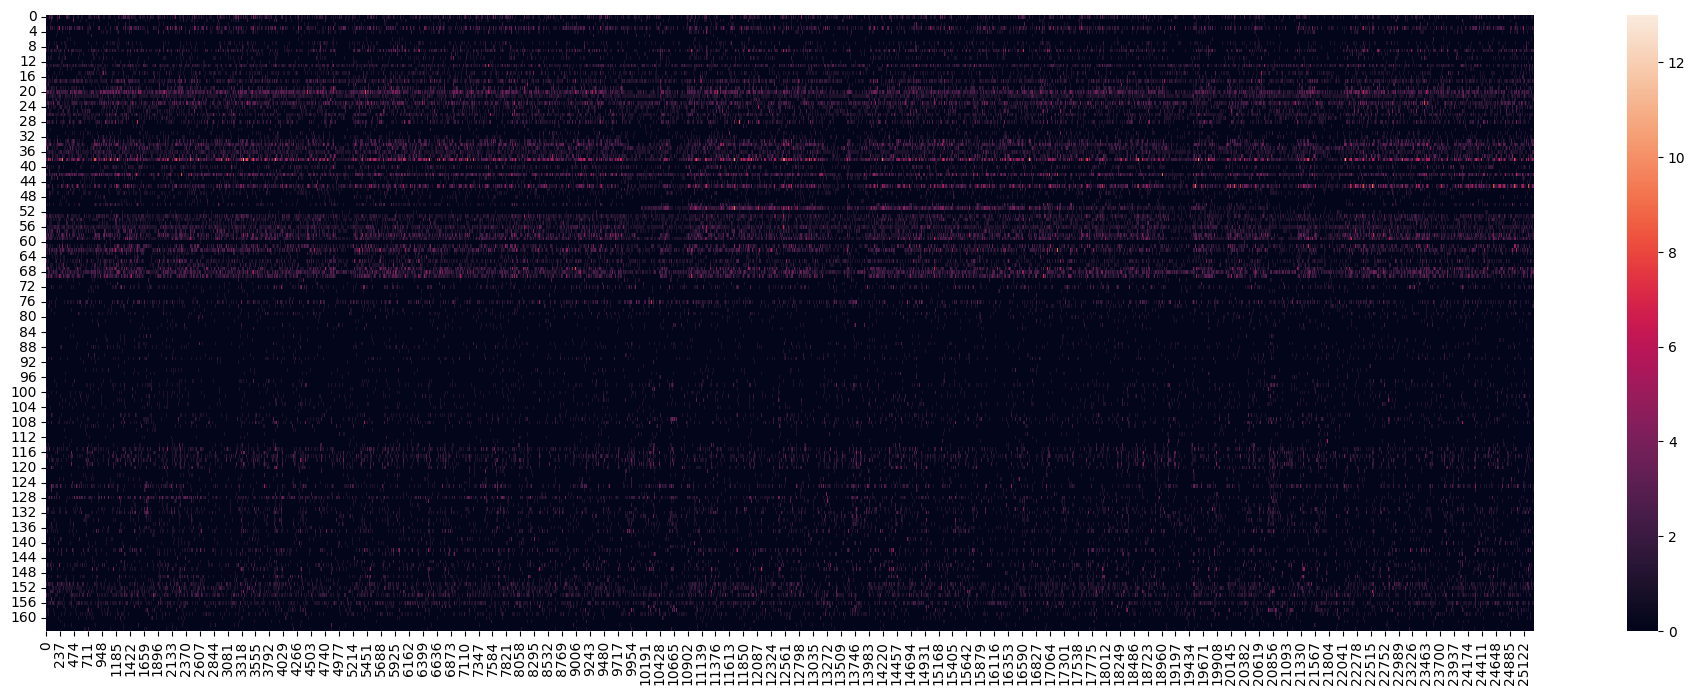

In [55]:
plt.figure(figsize=(24,8))
sns.heatmap(neural_data.T)
plt.show()


In [58]:
# Format for recurrent neural networks (e.g., Kalman filter and LSTM)
# Function to get the covariate matrix that includes spike history from previous bins
X = get_neural_covariates(neural_data,bins_before,bins_after,bins_current)
## Check this is correct
X = X[bins_before:-bins_after-1]   ## Removing NaNs

# Format for non-recurrent neural networks
#Put in "flat" format, so each "neuron / time" is a single feature
X_flat = X.reshape(X.shape[0],(X.shape[1]*X.shape[2]))

# Set decoding output
y = vels_binned[bins_before:-bins_after-1]  ## Removing index corresponding to NaNs of X



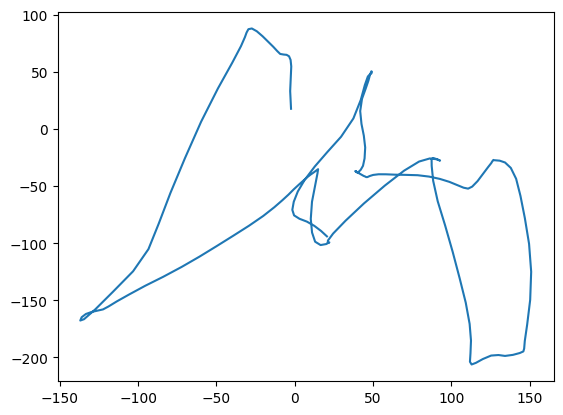

In [57]:
## Example of trajectory
plt.plot(np.cumsum(y[:200,0]),np.cumsum(y[:200,1]))
plt.show()

### Format of input and out for Kalman filter decoder

In [77]:
## Format of input
# X_kf = neural_data


#For the Kalman filter, we use the position, velocity, and acceleration as outputs
#Ultimately, we are only concerned with the goodness of fit of velocity (for this dataset)
#But using them all as covariates helps performance

#We will now determine position
pos_binned=np.zeros(vels_binned.shape) #Initialize 
pos_binned[0,:]=0 #Assume starting position is at [0,0]
#Loop through time bins and determine positions based on the velocities
for i in range(pos_binned.shape[0]-1): 
    pos_binned[i+1,0]=pos_binned[i,0]+vels_binned[i,0]*dt #Note that .05 is the length of the time bin
    pos_binned[i+1,1]=pos_binned[i,1]+vels_binned[i,1]*dt

#We will now determine acceleration    
temp=np.diff(vels_binned,axis=0)/dt #The acceleration is the difference in velocities across time bins 
acc_binned=np.concatenate((temp,temp[-1:,:]),axis=0) #Assume acceleration at last time point is same as 2nd to last

#The final output covariates include position, velocity, and acceleration
# y_kf=np.concatenate((pos_binned,vels_binned),axis=1)
y_kf=np.concatenate((pos_binned,vels_binned,acc_binned),axis=1)
y_kf.shape



(25299, 6)

### Split into train / test sets and run decoders



In [80]:
training_range = [0, 0.7]
testing_range = [0.7, 1]

num_examples=X.shape[0]
        
# Note that each range has an extra 1 bin at the beginning and end.
# Thus, the different sets don't overlap their data.
training_set=np.arange(int(np.round(training_range[0]*num_examples))+1,int(np.round(training_range[1]*num_examples))-1)
testing_set=np.arange(int(np.round(testing_range[0]*num_examples))+1,int(np.round(testing_range[1]*num_examples))-1)
#valid_set=np.arange(int(np.round(valid_range[0]*num_examples))+1,int(np.round(valid_range[1]*num_examples))-1)

X_train=X[training_set,:]
X_flat_train = X_flat[training_set,:]
y_train=y[training_set,:]
y_kf_train = y_kf[training_set,:]

X_test=X[testing_set,:]
X_flat_test= X_flat[testing_set,:]
y_test=y[testing_set,:]
y_kf_test = y_kf[testing_set,:]
# X_valid=X[valid_set,:]
# X_flat_valid= X_flat[valid_set,:]
# y_valid=y[valid_set,:]


### It is very important to perform z-scoring!!!

In [81]:
#Z-score "X" inputs. 
X_train = calc_zscores(X_train)
X_test = calc_zscores(X_test)

#Z-score "X_flat" inputs. 
X_flat_train = calc_zscores(X_flat_train)
X_flat_test = calc_zscores(X_flat_test)


#Zero-center outputs
y_train = calc_zerocenter(y_train)
y_test = calc_zerocenter(y_test)
y_kf_train = calc_zerocenter(y_kf_train)
y_kf_test = calc_zerocenter(y_kf_test)


In [82]:
X_train.shape, y_train.shape, X_flat_train.shape, y_kf_train.shape

((17698, 13, 164), (17698, 2), (17698, 2132), (17698, 6))

### Plot decoding results and calcualte decoding performance


In [83]:
def calc_R2(y_test,y_test_pred):
    """
    Parameters
    ----------
    y_test : matrix
    y_test_pred : matrix
    
    Returns
    -------
    R2_array: array
    """

    R2_list=[]
    for i in range(y_test.shape[1]):
        y_mean = np.mean(y_test[:,i])
        R2 = 1 - np.sum((y_test_pred[:,i]-y_test[:,i])**2) / np.sum((y_test[:,i] - y_mean)**2)
        R2_list.append(R2)
    R2_array=np.array(R2_list)
    return R2_array

#### (1) Linear decoder


In [85]:
model_lin=LinearDecoder()
model_lin.fit(X_flat_train,y_train)
y_pred_lin = model_lin.predict(X_flat_test)
#Get metric of fit
R2_lin = calc_R2(y_test,y_pred_lin)
print('R2:', R2_lin[0:2])

R2: [0.7628479  0.73691606]


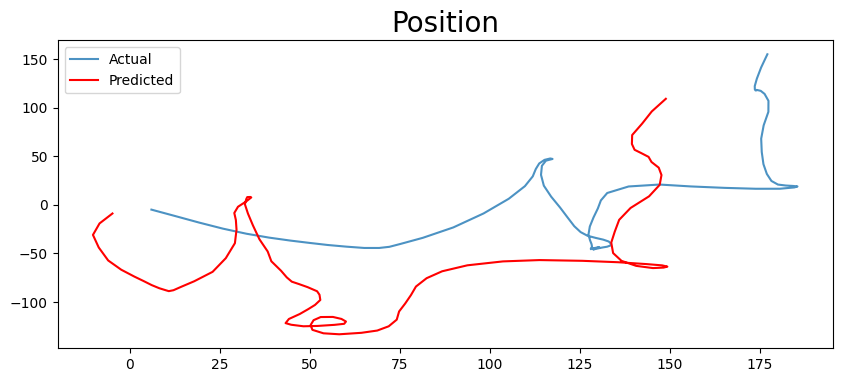

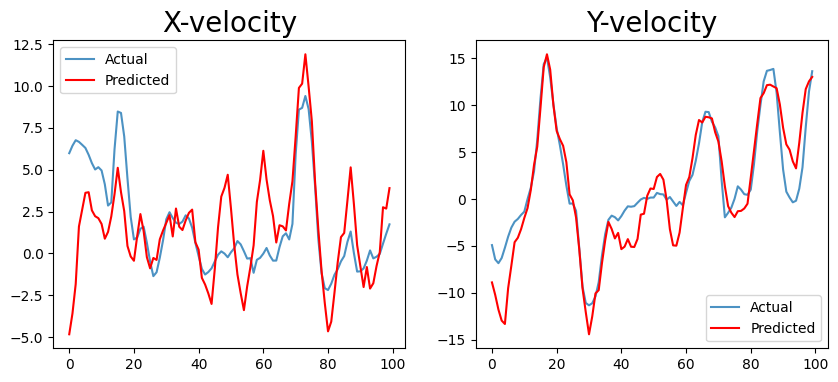

In [86]:
plt.figure(figsize = (10,4))
plt.title("Position", fontsize=20)
plt.plot(np.cumsum(y_test[:100,0]),np.cumsum(y_test[:100,1]), alpha = 0.8, label = "Actual")
plt.plot(np.cumsum(y_pred_lin[:100,0]),np.cumsum(y_pred_lin[:100,1]), color="r", label = "Predicted")
plt.legend()
plt.show()

plt.figure(figsize = (10,4))
plt.subplot(121)
plt.title("X-velocity", fontsize=20)
plt.plot(y_test[:100,0], alpha = 0.8, label = "Actual")
plt.plot(y_pred_lin[:100,0], color="r", label = "Predicted")
plt.legend()
plt.subplot(122)
plt.title("Y-velocity", fontsize=20)
plt.plot(y_test[:100,1], alpha = 0.8, label = "Actual")
plt.plot(y_pred_lin[:100,1], color="r", label = "Predicted")
       
plt.legend()
plt.show()

#### (2) Kalman filter decoder

In [89]:
X_train.shape, y_train.shape, y_kf_train.shape, X_flat_test.shape, y_test.shape, y_kf_test.shape

((17698, 13, 164), (17698, 2), (17698, 6), (7584, 2132), (7584, 2), (7584, 6))

In [94]:
model_kf = KalmanFilterDecoder()

model_kf.fit(X_flat_train,y_kf_train)

y_pred_kf = model_kf.predict(X_flat_test,y_kf_test)

R2_kf = calc_R2(y_kf_test,y_pred_kf)
print('R2:',R2_kf[2:4])

R2: [0.67278671 0.62112027]


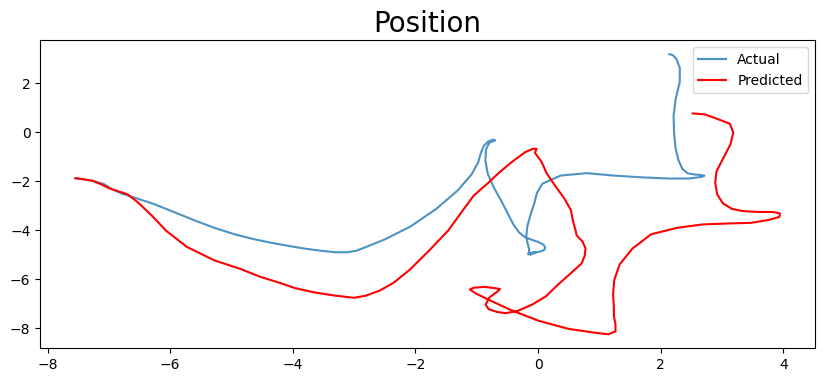

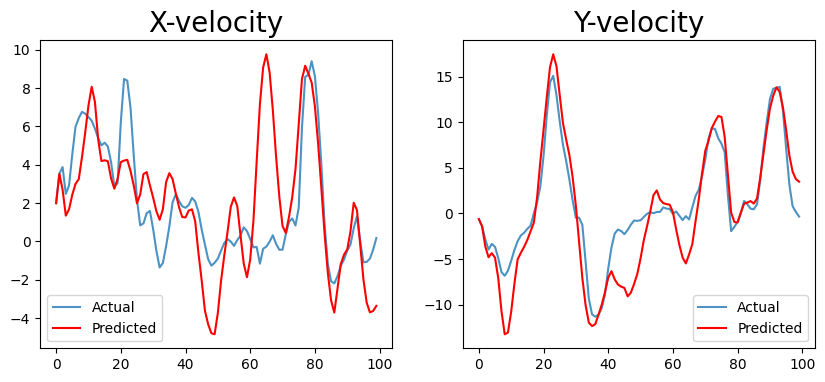

In [26]:
plt.figure(figsize = (10,4))
plt.title("Position", fontsize=20)
plt.plot(y_kf_test[:100,0],y_kf_test[:100,1], alpha = 0.8, label = "Actual")
plt.plot(y_pred_kf[:100,0],y_pred_kf[:100,1], color="r", label = "Predicted")
plt.legend()
plt.show()

plt.figure(figsize = (10,4))
plt.subplot(121)
plt.title("X-velocity", fontsize=20)
plt.plot(y_kf_test[:100,2], alpha = 0.8, label = "Actual")
plt.plot(y_pred_kf[:100,2], color="r", label = "Predicted")
plt.legend()
plt.subplot(122)
plt.title("Y-velocity", fontsize=20)
plt.plot(y_kf_test[:100,3], alpha = 0.8, label = "Actual")
plt.plot(y_pred_kf[:100,3], color="r", label = "Predicted")
       
plt.legend()
plt.show()

#### (3) Recurrent neural network decoder

In [29]:

class LSTMRegression(nn.Module):
    def __init__(self, input_size, output_size, units=400, dropout=0, num_epochs=200, verbose=True):
        super(LSTMRegression, self).__init__()
        self.units = units
        self.dropout = dropout
        self.num_epochs = num_epochs
        self.verbose = verbose
        self.lstm = nn.LSTM(input_size, hidden_size=self.units, dropout=self.dropout, batch_first=True)
        self.dropout_layer = nn.Dropout(self.dropout)
        self.linear = nn.Linear(self.units, output_size)
    
    def forward(self, x):
        output, _ = self.lstm(x)
        output = self.dropout_layer(output)
        output = self.linear(output[:, -1, :])
        return output

    def fit(self, X_train, y_train):
        self.train()
        criterion = nn.MSELoss()
        optimizer = optim.RMSprop(self.parameters())

        for epoch in range(self.num_epochs):
            optimizer.zero_grad()

            inputs = torch.Tensor(X_train)
            targets = torch.Tensor(y_train)

            outputs = self(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            if self.verbose and epoch % 10 == 0:
                print(f"Epoch {epoch+1}/{self.num_epochs}, Loss: {loss.item():.4f}")
        return loss

    def predict(self, X_test):
        self.eval()
        with torch.no_grad():
            inputs = torch.Tensor(X_test)
            outputs = self(inputs)
        return outputs.numpy()


In [31]:
model_lstm = LSTMRegression(input_size = 164, output_size = y_train.shape[1], units=400,dropout=0,num_epochs=200)

lstm_loss = model_lstm.fit(X_train,y_train)

y_pred_lstm = model_lstm.predict(X_test)

R2_lstm = calc_R2(y_test, y_pred_lstm)
print('R2:', R2_lstm)

Epoch 1/200, Loss: 37.6914
Epoch 11/200, Loss: 25.3562
Epoch 21/200, Loss: 11.2995
Epoch 31/200, Loss: 6.7419
Epoch 41/200, Loss: 4.8035
Epoch 51/200, Loss: 4.9814
Epoch 61/200, Loss: 2.1820
Epoch 71/200, Loss: 2.4853
Epoch 81/200, Loss: 1.3798
Epoch 91/200, Loss: 1.9352
Epoch 101/200, Loss: 0.5255
Epoch 111/200, Loss: 0.4631
Epoch 121/200, Loss: 0.4206
Epoch 131/200, Loss: 0.6313
Epoch 141/200, Loss: 0.3314
Epoch 151/200, Loss: 0.3297
Epoch 161/200, Loss: 1.3041
Epoch 171/200, Loss: 0.5316
Epoch 181/200, Loss: 0.0858
Epoch 191/200, Loss: 0.0596
R2: [0.77205431 0.74704864]


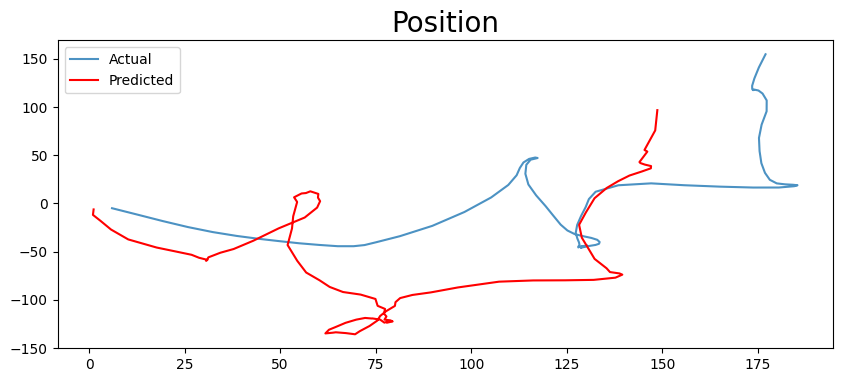

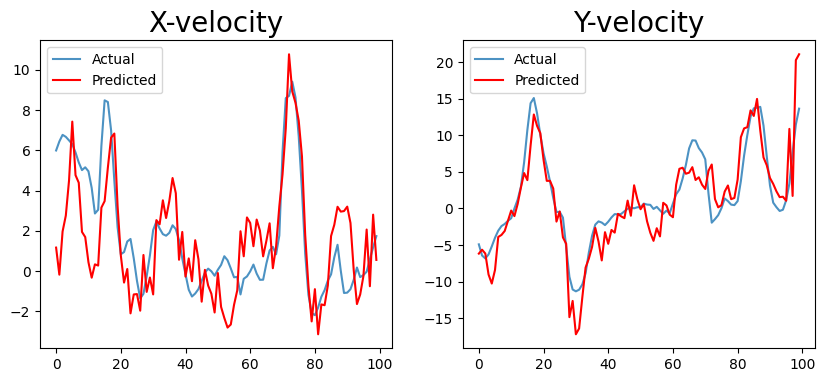

In [32]:
plt.figure(figsize = (10,4))
plt.title("Position", fontsize=20)
plt.plot(np.cumsum(y_test[:100,0]),np.cumsum(y_test[:100,1]), alpha = 0.8, label = "Actual")
plt.plot(np.cumsum(y_pred_lstm[:100,0]),np.cumsum(y_pred_lstm[:100,1]), color="r", label = "Predicted")
plt.legend()
plt.show()

plt.figure(figsize = (10,4))
plt.subplot(121)
plt.title("X-velocity", fontsize=20)
plt.plot(y_test[:100,0], alpha = 0.8, label = "Actual")
plt.plot(y_pred_lstm[:100,0], color="r", label = "Predicted")
plt.legend()
plt.subplot(122)
plt.title("Y-velocity", fontsize=20)
plt.plot(y_test[:100,1], alpha = 0.8, label = "Actual")
plt.plot(y_pred_lstm[:100,1], color="r", label = "Predicted")
       
plt.legend()
plt.show()